# Notebook 01 — Calibración COCO

**Parte 1** del trabajo: validar que las herramientas de interpretabilidad (cross-attention y Grad-CAM) funcionan correctamente en imágenes naturales donde el resultado correcto es visualmente obvio.

**Objetivo:** antes de analizar radiografías, confirmar que los heatmaps apuntan a los objetos correctos para cada palabra del caption en imágenes de MS-COCO.

**Outputs generados:**
- `outputs/parte1_coco/captions.json` — nombre de archivo + caption generado
- `outputs/parte1_coco/comparacion_<nombre>.png` — figura cross-att vs grad-cam por imagen

## 0. Configuración global

**Completar `IMAGES_DIR`** con la ruta a la carpeta que contiene las imágenes PNG/JPG.
Cambiar `N_IMAGES` para limitar cuántas procesar (útil en CPU).

In [51]:
# ── Completar antes de correr ──────────────────────────────────────────────
IMAGES_DIR = "../data/img_prueba"   # ← ruta absoluta o relativa a la carpeta con las imágenes

# cuántas imágenes procesar (None = todas las que haya en IMAGES_DIR)
N_IMAGES = 1 #None

## 1. Imports y paths

In [52]:
import json
import sys
from pathlib import Path

import torch

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.blip_loader import load_model_and_processor
from src.interpretability.cross_attention import eval_and_extract_cross_att
from src.interpretability.gradcam import compute_gradcam
from src.visualization.heatmap import plot_comparison_heatmaps

MODEL_DIR  = ROOT / "models" / "blip_base"
OUTPUT_DIR = ROOT / "outputs" / "parte1_coco"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

images_path = Path(IMAGES_DIR)
assert images_path.exists(), f"IMAGES_DIR no existe: {images_path}"

print(f"ROOT       : {ROOT}")
print(f"MODEL_DIR  : {MODEL_DIR}  (existe: {MODEL_DIR.exists()})")
print(f"IMAGES_DIR : {images_path.resolve()}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"Device     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"N_IMAGES   : {N_IMAGES if N_IMAGES is not None else 'todas'}")

ROOT       : /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning
MODEL_DIR  : /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/models/blip_base  (existe: True)
IMAGES_DIR : /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/data/img_prueba
Output dir : /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/outputs/parte1_coco
Device     : CPU
N_IMAGES   : 1


## 2. Cargar modelo

In [53]:
model, processor = load_model_and_processor(model_dir=MODEL_DIR)
device = next(model.parameters()).device
print(f"Modelo cargado en: {device}")

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Modelo cargado en: cpu


## 3. Cargar imágenes desde disco

In [54]:
from PIL import Image

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = sorted([p for p in images_path.iterdir() if p.suffix.lower() in extensions])

if N_IMAGES is not None:
    image_paths = image_paths[:N_IMAGES]

images = [Image.open(p).convert("RGB") for p in image_paths]
filenames = [p.name for p in image_paths]

print(f"Imágenes encontradas: {len(images)}")
for fname, img in zip(filenames, images):
    print(f"  {fname}  →  {img.size}")

Imágenes encontradas: 1
  prueba1.jpeg  →  (1200, 1600)


### Vista previa

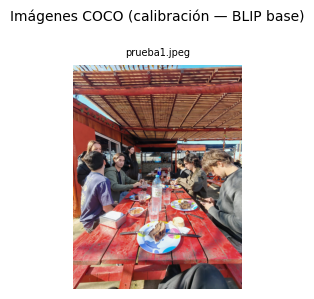

In [55]:
import matplotlib.pyplot as plt
import numpy as np

n = len(images)
n_cols = min(n, 5)
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3), dpi=100)
axes = np.array(axes).flatten()

for i, (img, fname) in enumerate(zip(images, filenames)):
    axes[i].imshow(img)
    axes[i].set_title(fname, fontsize=7)
    axes[i].axis("off")

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.suptitle("Imágenes COCO (calibración — BLIP base)", fontsize=10)
plt.tight_layout()
plt.show()

## 4. Cross-attention

In [56]:
from tqdm.notebook import tqdm

cross_att_results = []

model.eval()
for img in tqdm(images, desc="Cross-attention"):
    inputs = processor(images=img, return_tensors="pt").to(str(device))
    result = eval_and_extract_cross_att(model, processor, inputs, num_batch=1)
    cross_att_results.append(result[0])

print()
for fname, r in zip(filenames, cross_att_results):
    print(f"  {fname}: {r['caption']}")

Cross-attention:   0%|          | 0/1 [00:00<?, ?it/s]


  prueba1.jpeg: a group of people sitting at a table eating


## 5. Grad-CAM

> ⚠️ En CPU ~5–10 min por imagen. En GPU ~10–20 seg.

In [ ]:
# gradcam_results = []

# for i, img in enumerate(tqdm(images, desc="Grad-CAM")):
#     result = compute_gradcam(model, processor, [img], device=str(device))
#     gradcam_results.append(result[0])
#     print(f"  [{i}] {filenames[i]}: {result[0]['caption']}")

# print("\nGrad-CAM listo.")

Grad-CAM:   0%|          | 0/1 [00:00<?, ?it/s]

  [0] prueba1.jpeg: a group of people sitting at a table eating

Grad-CAM listo.


## 6. Verificación rápida — primera imagen

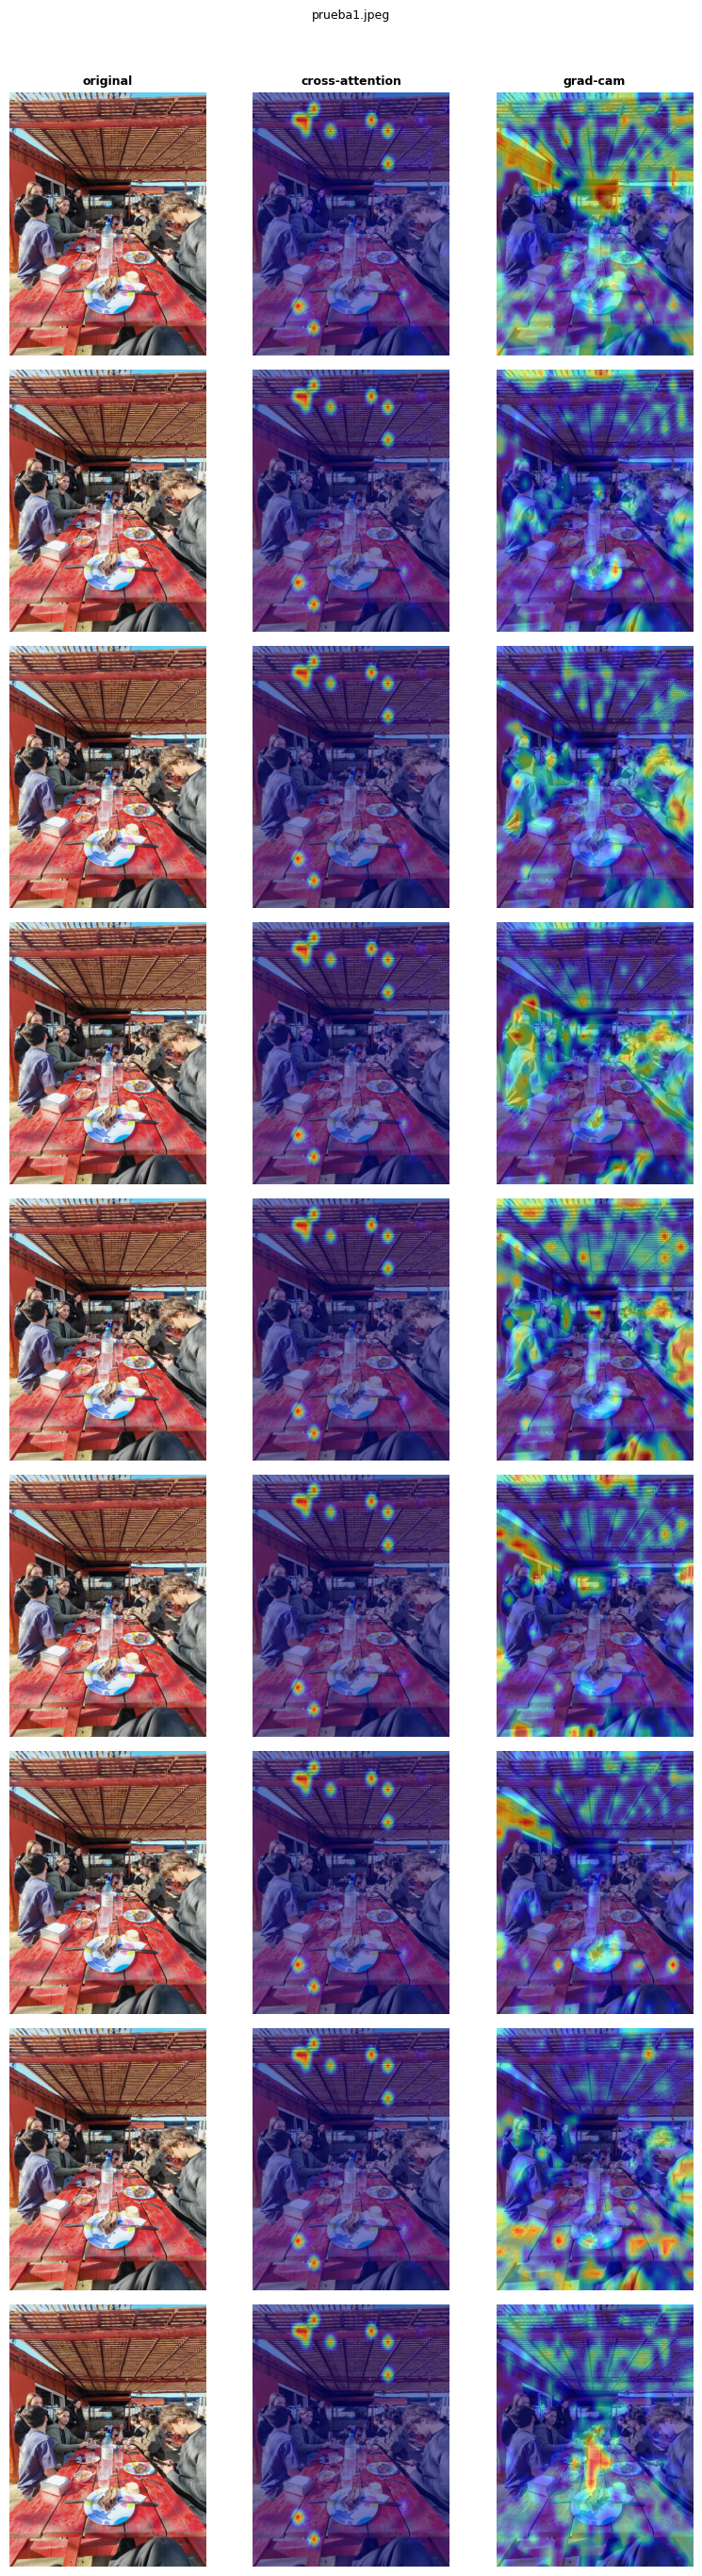

In [ ]:
# fig = plot_comparison_heatmaps(
#     image=images[0],
#     cross_att_results=cross_att_results[0],
#     gradcam_results=gradcam_results[0],
#     idx=0,
#     dpi=100,
# )
# plt.suptitle(filenames[0], fontsize=9, y=1.01)
# plt.tight_layout()
# plt.show()

### Ver una sola palabra

Útil para explorar imágenes con muchas palabras sin generar una figura enorme.

Palabras disponibles: ['a', 'group', 'of', 'people', 'sitting', 'at', 'a', 'table', 'eating']


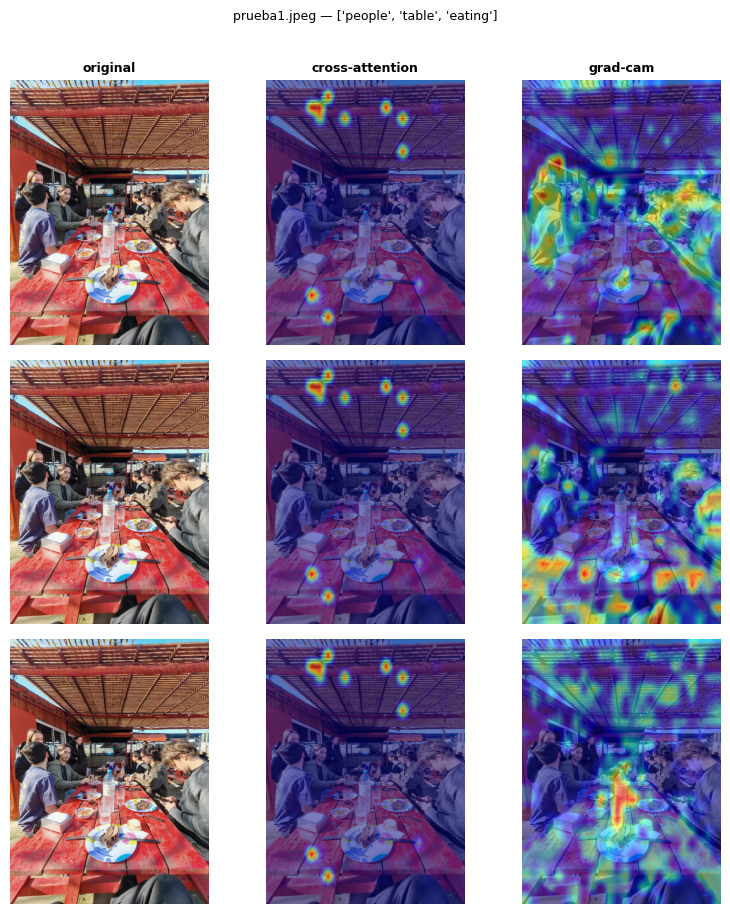

In [ ]:
# ver qué palabras hay disponibles en la primera imagen
print("Palabras disponibles:", [w for w, _ in cross_att_results[0]["maps"]])

# cambiar IMAGE_IDX y WORD para explorar
IMAGE_IDX = 0
# WORD = cross_att_results[0]["maps"][0][0]  # por defecto: primera palabra

INDICES_PALABRAS = [3, 7, 8]

# ca_f = {**cross_att_results[IMAGE_IDX],
#         "maps": [cross_att_results[IMAGE_IDX]["maps"][i] for i in INDICES_PALABRAS]}
# gc_f = {**gradcam_results[IMAGE_IDX],
#         "maps": [gradcam_results[IMAGE_IDX]["maps"][i] for i in INDICES_PALABRAS]}

fig = plot_comparison_heatmaps(images[IMAGE_IDX], ca_f, gc_f, dpi=100)
palabras = [cross_att_results[IMAGE_IDX]["maps"][i][0] for i in INDICES_PALABRAS]
plt.suptitle(f"{filenames[IMAGE_IDX]} — {palabras}", fontsize=9, y=1.01)
plt.tight_layout()
plt.show()


## 7. Guardar outputs

In [60]:
# 7a. captions.json
captions_data = [
    {
        "filename": filenames[i],
        "caption_generado": cross_att_results[i]["caption"],
    }
    for i in range(len(images))
]

captions_path = OUTPUT_DIR / "captions.json"
with open(captions_path, "w", encoding="utf-8") as f:
    json.dump(captions_data, f, ensure_ascii=False, indent=2)

print(f"captions.json guardado en: {captions_path}")

captions.json guardado en: /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/outputs/parte1_coco/captions.json


In [61]:
# 7b. figura de comparación por imagen
for i in range(len(images)):
    stem = Path(filenames[i]).stem
    out_path = OUTPUT_DIR / f"comparacion_{stem}.png"

    fig = plot_comparison_heatmaps(
        image=images[i],
        cross_att_results=cross_att_results[i],
        gradcam_results=gradcam_results[i],
        idx=0,
        dpi=200,
    )
    fig.suptitle(f"{filenames[i]} | {cross_att_results[i]['caption']}", fontsize=7, y=1.005)
    fig.savefig(out_path, bbox_inches="tight", dpi=200)
    plt.close(fig)
    print(f"  Guardado: {out_path.name}")

print(f"\nFiguras guardadas en: {OUTPUT_DIR}")

  Guardado: comparacion_prueba1.png

Figuras guardadas en: /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/outputs/parte1_coco


## 8. Resumen

In [62]:
print("=" * 60)
print("RESUMEN — Parte 1: Calibración COCO")
print("=" * 60)
print(f"Imágenes procesadas : {len(images)}")
print()
print("Captions generados por BLIP base:")
for item in captions_data:
    print(f"  {item['filename']:<30}  →  {item['caption_generado']}")
print()
print(f"Outputs en: {OUTPUT_DIR}")
print("  - captions.json")
for fname in filenames:
    print(f"  - comparacion_{Path(fname).stem}.png")

RESUMEN — Parte 1: Calibración COCO
Imágenes procesadas : 1

Captions generados por BLIP base:
  prueba1.jpeg                    →  a group of people sitting at a table eating

Outputs en: /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/outputs/parte1_coco
  - captions.json
  - comparacion_prueba1.png
